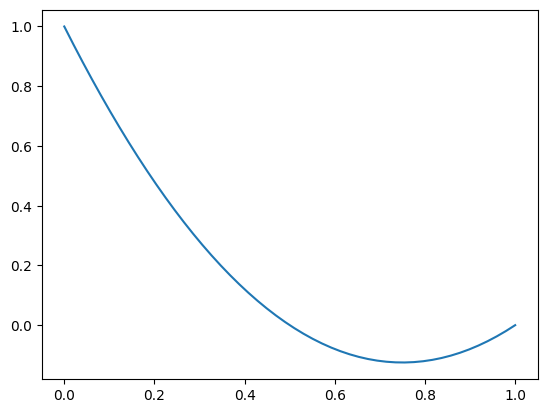

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def D(alpha):
    return 1 - 3*alpha +2*(alpha**2)

alphas = np.linspace(0, 1)

plt.plot(alphas, D(alphas))

In [16]:
def Ch(gamma, tau, alpha, theta_h):
    d = D(alpha)
    return gamma * tau * d - gamma * (1 - theta_h)

def Cl(gamma, tau, alpha, theta_h, theta_l):
    d = D(alpha)
    return gamma * (1 - theta_h) - (1-theta_l) + tau * (1 - gamma) * d

theta_h = 2 / 3
theta_l = 5 / 6
num_types = 10000
alphas = np.linspace(0, 0.5, num_types)
gamma = 0.9
tau = 1

In [24]:
np.concatenate((np.linspace(0.01, 0.49, 49), np.linspace(0.51, 0.65, 15)))

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56,
       0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65])

In [21]:
np.linspace(0.51, 0.75, 25),

(array([0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61,
        0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72,
        0.73, 0.74, 0.75]),)

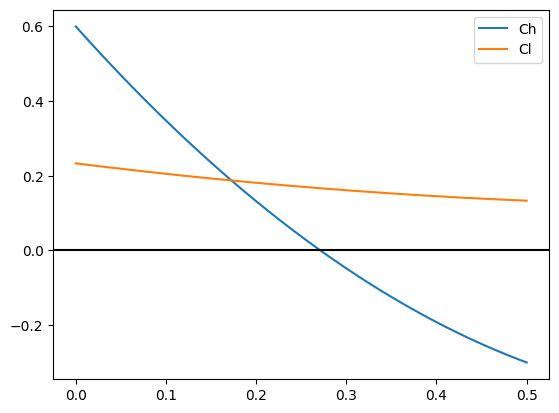

In [17]:
plt.plot(alphas, Ch(gamma, tau, alphas, theta_h), label="Ch")
plt.plot(alphas, Cl(gamma, tau, alphas, theta_h, theta_l), label="Cl")
plt.axhline(y=0, c="k")
plt.legend()
plt.show()

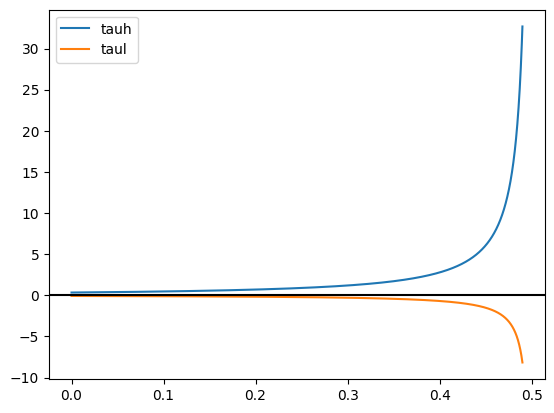

In [31]:
def tauh(gamma, tau, alpha, theta_h):
    d = D(alpha)
    return (1 - theta_h) / d

def taul(gamma, tau, alpha, theta_h, theta_l):
    d = D(alpha)
    return ((1 - theta_l) - gamma * (1 - theta_h)) / ((1 - gamma) * d)

theta_h = 2 / 3
theta_l = 5 / 6
num_types = 10000
alphas = np.linspace(0, 0.49, num_types)
gamma = 0.6

plt.plot(alphas, tauh(gamma, tau, alphas, theta_h), label="tauh")
plt.plot(alphas, taul(gamma, tau, alphas, theta_h, theta_l), label="taul")
plt.axhline(y=0, c="k")
#plt.ylim(top=1, bottom=-0.05)
plt.legend()
plt.show()

In [27]:
2/3

0.6666666666666666

In [235]:
from scipy.optimize import minimize 

def objective(vars):
    x_l, x_h, trans_h, trans_l = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def constraint1(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * (x_h - x_l) - (trans_h - trans_l)


def constraint2(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * (x_l - x_h) - (trans_l - trans_h)


def constraint3(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * x_l - trans_l

def constraint4(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * x_h - trans_h

bounds = [(-1, 1), (-1, 1), (0, None), (0, None)]

# Initial guess for the variables
tau = 0.5
prob_state0 = 0.3
theta_h = 2/3
theta_l = 5/6
gamma = 0.4


constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4},
    ]
x0 = [-1, -1, 1, 1]
result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

    
result.x

array([-2.77828308e-16,  1.00000000e+00,  3.33333333e-01,  9.42055446e-16])

In [54]:
def calculate_exerpiment_value(informativeness: float, type: float) -> float:
    return np.maximum(
        -10,
        type * informativeness
        + 1
        + np.minimum(-informativeness, 0)
        - (1 - type) * (type <= 0.5)
        - type * (type > 0.5),
    )

(0.0, 0.4257575757575758)

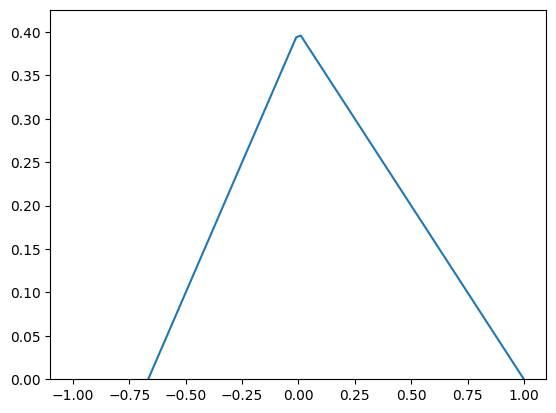

In [58]:
informativeness = np.linspace(-1, 1, 100)
prob_state0 = 0.6

plt.plot(informativeness, calculate_exerpiment_value(informativeness, prob_state0))
plt.ylim(bottom=0)

In [176]:
def actions(
    informativeness: float, types: np.ndarray[float], sample_size: int, p
):
    actions = []
    for i in range(100):
        state = np.random.choice([0, 1], p=[p, 1-p])
        
        prob_signal0_state0 = 1 if informativeness > 0 else 1 + informativeness
        prob_signal1_state1 = 1 if informativeness <= 0 else 1 - informativeness

        prob_signal0_state1 = 1 - prob_signal1_state1
        prob_signal1_state0 = 1 - prob_signal0_state0

        prob_signal0 = prob_signal0_state0 * types + prob_signal0_state1 * (1 - types)
        prob_signal1 = prob_signal1_state0 * types + prob_signal1_state1 * (1 - types)

        prob_state0_signal0 = prob_signal0_state0 * types / prob_signal0
        prob_state0_signal1 = prob_signal1_state0 * types / prob_signal1

        signals = np.random.uniform(0, 1, size=sample_size) <= (
            prob_signal1_state1 if state == 1 else prob_signal1_state0
        )

        probs_state0 = signals * prob_state0_signal1 + (1 - signals) * prob_state0_signal0

        action = (probs_state0 < 0.5).mean(axis=0)
        actions.append(action)
   
    return int(np.mean(actions) >= 0.5)

In [232]:
informativeness = 0.999

prob_action1s = []
iss = np.linspace(-0.99, 0.99, 50)
for informativeness in iss:
    prob_state0 = 0.1
    states = np.random.choice([0, 1], p=[prob_state0, 1-prob_state0], size=10000)
    prob_signal0_state0 = 1 if informativeness > 0 else 1 + informativeness
    prob_signal1_state1 = 1 if informativeness <= 0 else 1 - informativeness

    prob_signal0_state1 = 1 - prob_signal1_state1
    prob_signal1_state0 = 1 - prob_signal0_state0

    prob_action0 = np.mean((states * prob_signal0_state1 + (1-states) * prob_signal0_state0))
    prob_action0, 1-prob_action0
    prob_action1s.append(1-prob_action0)

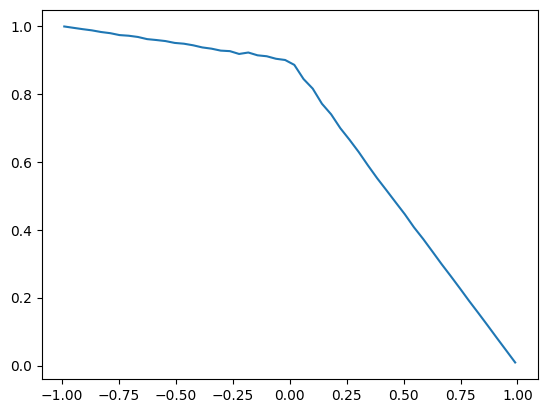

In [233]:
plt.plot(iss, prob_action1s)

In [197]:
np.mean((states * prob_signal0_state1 + (1-states) * prob_signal0_state0))

np.float64(0.8198000000000002)

In [191]:
prob_signal0_state1

0.5

In [180]:
prob_state0s = np.linspace(0.01, 0.99)

allocation = -0.7
prob_state0 = 0.1
type = 0.7
allocations = np.linspace(-0.99, 0.99, 21)
for allocation in allocations:
    print(allocation, actions(allocation, type, 10000, p=prob_state0))

-0.99 0
-0.891 0
-0.792 0
-0.693 0
-0.594 0
-0.495 0
-0.3959999999999999 1
-0.29699999999999993 1
-0.19799999999999995 1
-0.09899999999999998 1
0.0 1
0.09899999999999998 1
0.19800000000000018 1
0.29700000000000015 1
0.39600000000000013 1
0.4950000000000001 0
0.5940000000000001 0
0.6930000000000001 0
0.792 0
0.891 0
0.99 0


In [178]:
prob_state0s = np.linspace(0.01, 0.99)

allocation = 0.999

plt.plot(prob_state0s, actions(allocation, prob_state0s, 100000, p=prob_state0))

ValueError: operands could not be broadcast together with shapes (100000,) (50,) 